Small [[18, 4, 4]] BB code as an example

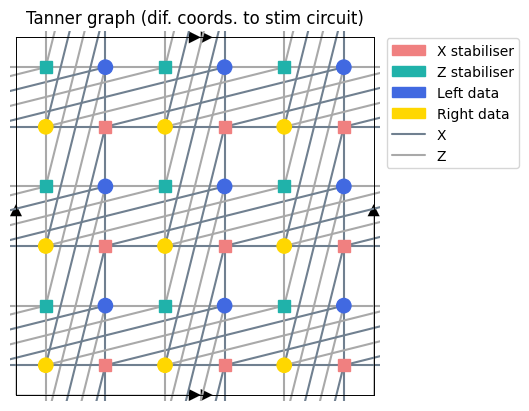

In [1]:
import stim
import sys
import os
sys.path.append(os.path.abspath("../src"))
from bb_ions import *

# Clear last example circuits and remake directories:
empty_folder('example_circuits')
empty_folder('example_circuit_diagrams')

# Define code:

# [[18, 4, 4]] BB6 (weight-6 stabilisers) code from Wang et al. [2503.22071]
l = 3
m = 3
# A = x + y^0 + y^2
# B = y + x^0 + x^2
Aij = [(1,0), (0,0), (0,2)]  # each tuple (i, j) is for term x^i⋅y^j
Bij = [(0,1), (0,0), (2,0)]
d = 4
code = get_code_params(l, m, Aij, Bij, d)

code.tanner_graph

In [2]:
# Generate circuits:

ps = [0.001, 0.002] # physical error rate values
memory_basis = 'Z'
num_rounds = code.d_max

for p in ps:

    circuit = make_BB_circuit(  # see src/bb_ions/circfuncs for explanation of make_BB_circuit inputs
        code,  
        p,  
        errors = tham_modules_errors(p), # see src/bb_ions/noisefuncs for different noise models
        idle_during = tham_modules_idle_errors(p),
        num_syndrome_extraction_cycles = num_rounds,  
        memory_basis = 'Z',
    )

    

    # Save circuit and diagram:
    filename = f"nkd=[[{code.n}_{code.k}_{code.d_max}]],p={p},b={memory_basis},r={num_rounds},l={l},m={m},A='{''.join(str(x) + str(y) for x, y in Aij)}',B='{''.join(str(x) + str(y) for x, y in Bij)}'"
    circuit.to_file(f"example_circuits/{filename}.stim")
    
    svg = str(circuit.diagram("timeline-svg"))
    with open(f"example_circuit_diagrams/{filename}.svg", "w", encoding="utf-8") as f: f.write(svg)

In [6]:
# # Run memory experiment simulations:

import sinter
import glob
from stimbposd import SinterDecoder_BPOSD, sinter_decoders
import multiprocessing

circuit_paths = glob.glob(f"example_circuits/nkd=[[{code.n}_{code.k}_{code.d_max}*.stim")

csv_path = "example_stats/collected_stats.csv"

tasks = [
    sinter.Task(
        circuit_path = path,
        json_metadata = sinter.comma_separated_key_values(path),
    )
    for path in circuit_paths
]


empty_folder('example_stats') # clear previous example stats

# Collect new stats:
samples = sinter.collect(
    num_workers=multiprocessing.cpu_count(),
    max_shots=1000,
    print_progress = True,
    max_errors=10,
    tasks = tasks,
    decoders=['bposd'],
    save_resume_filepath = csv_path,
    custom_decoders = {
        "bposd": SinterDecoder_BPOSD( # using settings from Ye Delfosse long chain paper [2503.22071] as I have found this to be very fast for only a small hit to performance.
            max_bp_iters = 10_000, 
            bp_method = "min_sum", 
            osd_method = "osd_cs", 
            osd_order = 5 
        )
    },
    )

Starting 8 workers...
2 tasks left:
  workers decoder eta shots_left errors_left json_metadata                                               
        4   bposd <1m        983          10 nkd=[[18_4_4]],p=0.001,b=Z,r=4,l=3,m=3,A='100002',B='010020'
        4   bposd   ?       1000          10 nkd=[[18_4_4]],p=0.002,b=Z,r=4,l=3,m=3,A='100002',B='010020'
2 tasks left:
  workers decoder eta shots_left errors_left json_metadata                                               
        4   bposd <1m        948           9 nkd=[[18_4_4]],p=0.001,b=Z,r=4,l=3,m=3,A='100002',B='010020'
        4   bposd <1m        983           9 nkd=[[18_4_4]],p=0.002,b=Z,r=4,l=3,m=3,A='100002',B='010020'
2 tasks left:
  workers decoder eta shots_left errors_left json_metadata                                               
        4   bposd <1m        948           9 nkd=[[18_4_4]],p=0.001,b=Z,r=4,l=3,m=3,A='100002',B='010020'
        4   bposd <1m        982           9 nkd=[[18_4_4]],p=0.002,b=Z,r=4,l=3,m=3,A='1

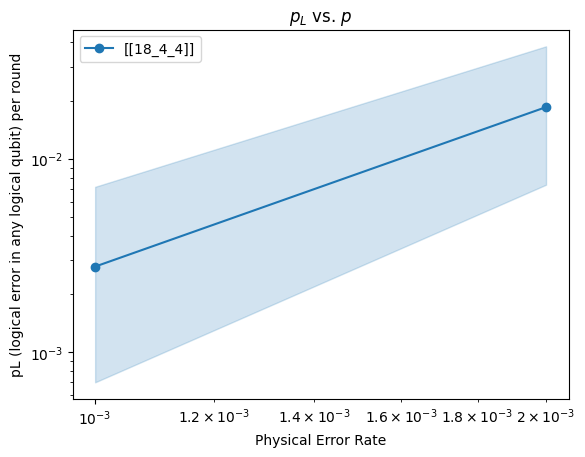

In [8]:
# Plot results:

import matplotlib.pyplot as plt

# Plot:
collected_stats = sinter.stats_from_csv_files(f'example_stats/collected_stats.csv')

fig, ax = plt.subplots(1, 1)

sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['nkd'],
    failure_units_per_shot_func = lambda stats: stats.json_metadata['r'], # set as num_rounds ('r') failure units to find pL per round
)

ax.loglog()
ax.legend()
ax.set_title("$p_L$ vs. $p$")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("pL (logical error in any logical qubit) per round");